In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"D:\SMART COACH\dataset\passenger_detail.csv")
print(df.head())

   id  passenger_name  age       gender  train_no booking_type       source  \
0   1    Nert Spitell   54       Female     84471       Direct        Salem   
1   2   Lelah Manston   76  Genderfluid     75255       Tatkal   Coimbatore   
2   3  Lodovico Dicke   36         Male     88415      Counter  Tirunelveli   
3   4  Ruperta Talloe   16       Female     96439       Online      Chennai   
4   5  Daveen Wakeley   37  Genderfluid     80648       Direct  Tirunelveli   

  destination coach  seat_no  fare travel_date ticket_status  
0     Madurai    A2       53   224   1/17/2026     Confirmed  
1     Chennai    B1       41  2102    9/1/2018       Waiting  
2       Salem    S1       29  2117   3/26/2025           RAC  
3      Trichy    A1       52  1932   3/10/2019       Waiting  
4      Trichy    D1       24   713   7/25/2020     Cancelled  


In [3]:
df = df.drop(columns=['passenger_name'])

In [4]:
encoder = LabelEncoder()
cols = [
    'gender',
    'booking_type',
    'ticket_status',
    'source',
    'destination',
    'coach'
]
for col in cols:
    df[col] = encoder.fit_transform(df[col])

In [5]:
X = df[[
    'age',
    'gender',
    'fare',
    'booking_type',
    'source',
    'destination'
]]
y = df['ticket_status']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=10
)
model.fit(X_train, y_train)
print("Random Forest Model Trained")

Random Forest Model Trained


In [8]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.25


In [11]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 7  7 15 10]
 [17 12 11  8]
 [11 16 23  9]
 [17 16 13  8]]
Classification Report:
              precision    recall  f1-score   support

           0       0.13      0.18      0.15        39
           1       0.24      0.25      0.24        48
           2       0.37      0.39      0.38        59
           3       0.23      0.15      0.18        54

    accuracy                           0.25       200
   macro avg       0.24      0.24      0.24       200
weighted avg       0.25      0.25      0.25       200



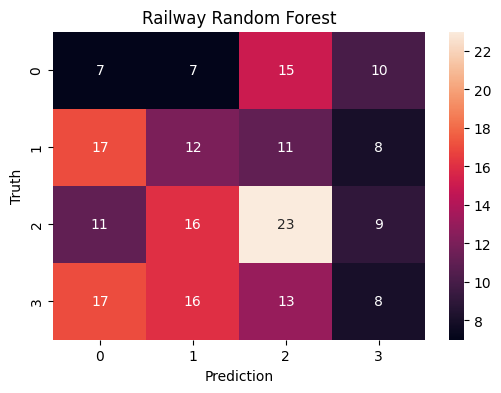

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True)
plt.title("Railway Random Forest")
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()

In [13]:
joblib.dump(model, "random_forest_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
